# Linear and Multiple Regression — Practice

This notebook is based only on the concepts covered in the lecture:

- Preparing \(X\) and \(y\)
- Initializing parameters
- Making predictions
- Calculating prediction error
- Cost function
- Gradient Descent
- Learning rate
- Best-fit line
- Multiple Linear Regression
- Coefficient interpretation
- Vectorized form
- Regression evaluation
- `scikit-learn` workflow

The tasks are challenging, but they do not require concepts outside the lecture.

# 1. Import Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Libraries imported successfully.")

Libraries imported successfully.


# Task 1 — Compare Candidate Regression Lines

A model uses:

$$
\hat{y} = \theta_0 + \theta_1x
$$

You are given a small dataset and three candidate parameter pairs.

### Required

1. Calculate predictions for every candidate.
2. Calculate the error for every observation.
3. Calculate the cost:

$$
J(\theta_0,\theta_1)
=
\frac{1}{2m}
\sum_{i=1}^{m}
(\hat{y}^{(i)}-y^{(i)})^2
$$

4. Create a comparison table.
5. Select the candidate with the lowest cost.
6. Plot all candidate lines with the data.

In [3]:
task1_df = pd.DataFrame({
    "x": [1, 2, 3, 4, 5],
    "y": [7, 9, 13, 15, 18]
})

candidate_parameters = {
    "Candidate A": (0, 3),
    "Candidate B": (4, 2.5),
    "Candidate C": (6, 2)
}

display(task1_df)

,x,y
0,1,7
1,2,9
2,3,13
3,4,15
4,5,18


In [4]:
c1_theta_0, c1_theta_1 = candidate_parameters["Candidate A"]
c2_theta_0, c2_theta_1 = candidate_parameters["Candidate B"]
c3_theta_0, c3_theta_1 = candidate_parameters["Candidate C"]

In [5]:
# Calculate predictions for every candidate.
c1 = c1_theta_0 + c1_theta_1 * task1_df["x"]
c2 = c2_theta_0 + c2_theta_1 * task1_df["x"]
c3 = c3_theta_0 + c3_theta_1 * task1_df["x"]

In [6]:
# Calculate the error for every observation.
c1_error = c1 - task1_df["y"]
c2_error = c2 - task1_df["y"]
c3_error = c3 - task1_df["y"]

In [7]:
# Calculate the cost:
m = len(task1_df)
c1_cost = (c1_error ** 2).sum() / (2 * m)
c2_cost = (c2_error ** 2).sum() / (2 * m)
c3_cost = (c3_error ** 2).sum() / (2 * m)

In [8]:
#  Create a comparison table.
comparison_df = pd.DataFrame({
    "Candidate": ["Candidate A", "Candidate B", "Candidate C"],
    "Error": [c1_error.sum(), c2_error.sum(), c3_error.sum()],
    "Cost": [c1_cost, c2_cost, c3_cost]
})

display(comparison_df)

,Candidate,Error,Cost
0,Candidate A,-17.0,5.900
1,Candidate B,-4.5,0.575
2,Candidate C,-2.0,0.800


In [9]:
# Select the candidate with the lowest cost.
print(f"The candidate with the lowest cost is {candidate_parameters["Candidate B"]}.")

The candidate with the lowest cost is (4, 2.5).


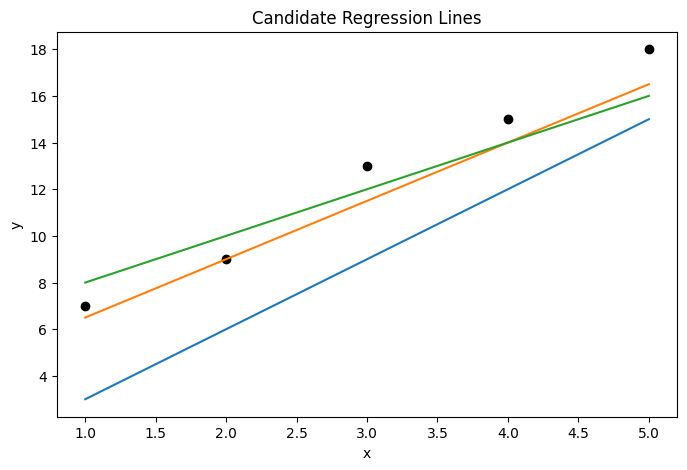

In [10]:
# Plot all candidate lines with the data.
x = task1_df["x"]
y = task1_df["y"]

plt.figure(figsize=(8,5))

plt.scatter(x, y, color="black", label="Data")

for name, (theta0, theta1) in candidate_parameters.items():
    y_pred = theta0 + theta1 * x
    plt.plot(x, y_pred, label=name)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Candidate Regression Lines")
plt.show()

### Interpretation Questions

1. Which candidate produced the lowest cost?
2. Did the best line pass through every point?
3. Why is the lowest-cost line considered the best among these candidates?

In [11]:
# Which candidate produced the lowest cost?
# The candidate with the lowest cost is B (4, 2.5)

# Did the best line pass through every point?
# No

# Why is the lowest-cost line considered the best among these candidates?
# It has the lowest cost among the three candidates

# Task 2 — Perform One Gradient Descent Update

Use the following equations:

Prediction:

$$
\hat{y}^{(i)} = \theta_0 + \theta_1x^{(i)}
$$

Gradients:

$$
\frac{\partial J}{\partial\theta_0}
=
\frac{1}{m}
\sum_{i=1}^{m}
(\hat{y}^{(i)}-y^{(i)})
$$

$$
\frac{\partial J}{\partial\theta_1}
=
\frac{1}{m}
\sum_{i=1}^{m}
(\hat{y}^{(i)}-y^{(i)})x^{(i)}
$$

Updates:

$$
\theta_0 := \theta_0 - \alpha \frac{\partial J}{\partial\theta_0}
$$

$$
\theta_1 := \theta_1 - \alpha \frac{\partial J}{\partial\theta_1}
$$

### Required

Start with:

- \(\theta_0 = 0\)
- \(\theta_1 = 0\)
- \(\alpha = 0.01\)

Then:

1. Calculate the initial predictions.
2. Calculate both gradients.
3. Update both parameters once.
4. Calculate the cost before and after the update.
5. Explain whether the update improved the model.

In [12]:
task2_df = pd.DataFrame({
    "x": [1, 2, 3, 4],
    "y": [5, 8, 11, 14]
})

display(task2_df)

,x,y
0,1,5
1,2,8
2,3,11
3,4,14


In [13]:
# Calculate the initial predictions.
theta_0 = 0
theta_1 = 0
alpha = 0.01

m = len(task2_df)

predictions = theta_0 + theta_1 * task2_df["x"]

In [14]:
# Calculate both gradients.
gradients_0 = (predictions - task2_df["y"]).sum() / m
gradients_1 = ((predictions - task2_df["y"]) * task2_df["x"]).sum() / m

In [15]:
# Update both parameters once.
theta_0 = theta_0 - alpha * gradients_0
theta_1 = theta_1 - alpha * gradients_1

In [16]:
predictions_after = theta_0 + theta_1 * task2_df["x"]

In [17]:
# before
error = predictions - task2_df["y"]
m = len(task2_df)
cost = (error ** 2).sum() / (2 * m)

# after
error_after = predictions_after - task2_df["y"]
cost_after = (error_after ** 2).sum() / (2 * m)

In [18]:
print(f"Cost before update: {cost}")
print(f"Cost after update: {cost_after}")

Cost before update: 50.75
Cost after update: 42.63841875


### Interpretation Questions

1. Did the cost decrease after one update?
2. Why must both gradients be calculated before updating either parameter?
3. What would happen if the learning rate were zero?

In [19]:
# Did the cost decrease after one update?
# Yes

# Why must both gradients be calculated before updating either parameter?
# so that both updates are based on the same current values of theta_0 and theta_1

# What would happen if the learning rate were zero?
# the parameters would never update, so the model would never learn or reduce the cost

# Task 3 — Build Simple Linear Regression from Scratch

Build a complete Simple Linear Regression model without `scikit-learn`.

### Required Functions

1. `predict()`
2. `compute_cost()`
3. `compute_gradients()`
4. `gradient_descent()`

### Required Outputs

- Learned intercept
- Learned slope
- Final equation
- Cost history
- Best-fit line
- Prediction table
- MAE, MSE, RMSE, and \(R^2\)
- Prediction for \(x=7.5\)

In [20]:
task3_df = pd.DataFrame({
    "study_hours": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    "score": [45, 50, 56, 60, 65, 72, 78, 83, 88, 94]
})

display(task3_df)

,study_hours,score
0,1,45
1,2,50
2,3,56
3,4,60
4,5,65
5,6,72
6,7,78
7,8,83
8,9,88
9,10,94


### Hints

- Use NumPy arrays.
- Start with `theta_0 = 0` and `theta_1 = 0`.
- Try `learning_rate = 0.01`.
- Try `iterations = 2000`.
- Store the cost after every iteration.

In [21]:
X = task3_df["study_hours"]
y = task3_df["score"]

In [22]:
def predict(x_values, theta_0, theta_1):
    return theta_0 + theta_1 * x_values

In [23]:
def compute_cost(x_values, y_values, theta_0, theta_1):
    predictions = predict(x_values, theta_0, theta_1)
    error = predictions - y_values
    cost = error ** 2
    return np.sum(cost) / (2 * len(x_values))

In [24]:
def compute_gradients(x_values, y_values, theta_0, theta_1):
    predictions = predict(x_values, theta_0, theta_1)

    errors = predictions - y_values

    gradient_0 = np.mean(errors)
    gradient_1 = np.mean(errors * x_values)

    return gradient_0, gradient_1

In [25]:
def gradient_descent(
    x_values,
    y_values,
    theta_0=0.0,
    theta_1=0.0,
    learning_rate=0.01,
    iterations=2000
):
    cost_history = []

    for iteration in range(iterations):
        gradient_0, gradient_1 = compute_gradients(x_values, y_values, theta_0, theta_1)
        theta_0 = theta_0 - (learning_rate * (gradient_0))
        theta_1 = theta_1 - (learning_rate * (gradient_1))
        cost = compute_cost(x_values, y_values, theta_0, theta_1)
        cost_history.append(cost)

    return theta_0, theta_1, cost_history

In [26]:
learned_theta_0, learned_theta_1, cost_history = gradient_descent(X, y)


print("Learned intercept:", learned_theta_0)
print("Learned slope:", learned_theta_1)
print("Final cost:", cost_history[-1])

Learned intercept: 38.44076085106003
Learned slope: 5.553056692137298
Final cost: 0.2316942729719665


In [27]:
def regression_metrics(y_true, y_pred):
    mae = np.mean(np.abs(y_true - y_pred))
    mse = np.mean((y_true - y_pred) ** 2)
    rmse = np.sqrt(mse)

    sum_squared_residuals = np.sum((y_true - y_pred) ** 2)
    total_sum_of_squares = np.sum((y_true - np.mean(y_true)) ** 2)
    r2 = 1 - sum_squared_residuals / total_sum_of_squares

    return mae, mse, rmse, r2

In [28]:
output = {
    "Intercept": learned_theta_0,
    "Slope": learned_theta_1,
    "Equation": f"y = {learned_theta_0:.2f} + {learned_theta_1:.2f}x",
    "Cost History": cost_history[-1],
}
display(output)

{'Intercept': np.float64(38.44076085106003),
 'Slope': np.float64(5.553056692137298),
 'Equation': 'y = 38.44 + 5.55x',
 'Cost History': np.float64(0.2316942729719665)}

In [29]:
display(cost_history[-10:-1])

[np.float64(0.2329865290051975),
 np.float64(0.23284051870567138),
 np.float64(0.2326951209383859),
 np.float64(0.23255033313369222),
 np.float64(0.2324061527327151),
 np.float64(0.2322625771873182),
 np.float64(0.2321196039600494),
 np.float64(0.23197723052411318),
 np.float64(0.23183545436330072)]

In [30]:
def regression_metrics(y_true, y_pred):

    mae = np.mean(np.abs(y_true - y_pred))
    mse = np.mean((y_true - y_pred) ** 2)
    rmse = np.sqrt(mse)

    sum_squared_residuals = np.sum((y_true - y_pred) ** 2)
    total_sum_of_squares = np.sum((y_true - np.mean(y_true)) ** 2)
    r2 = 1 - sum_squared_residuals / total_sum_of_squares

    return mae, mse, rmse, r2

In [31]:
mae, mse, rmse, r2 = regression_metrics(y, predict(X, learned_theta_0, learned_theta_1))

print("MEA: ", mae)
print("MSE: ", mse)
print("RMSE: ", rmse)
print("R2: ", r2)

MEA:  0.5728879445151229
MSE:  0.463388545943933
RMSE:  0.6807264839448609
R2:  0.998127647396081


In [32]:
test_x = 7.5
test_y = predict(test_x, learned_theta_0, learned_theta_1)

print(f"Test X: {test_x}")
print(f"Prediction for x={test_x}: {test_y:.2f}")

Test X: 7.5
Prediction for x=7.5: 80.09


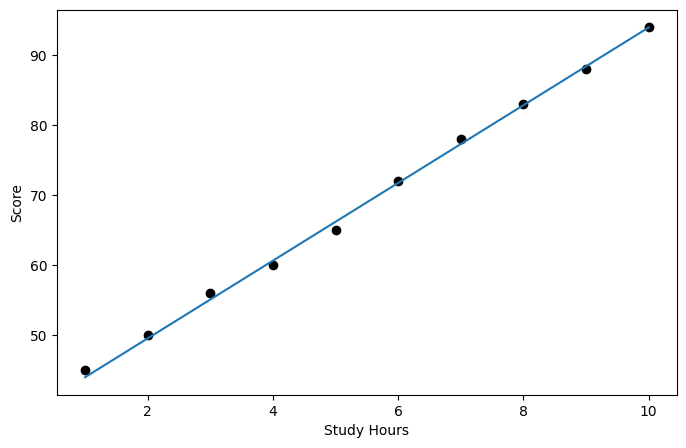

In [33]:
x = task3_df["study_hours"]
y = task3_df["score"]

plt.figure(figsize=(8,5))

plt.scatter(x, y, color="black", label="Data")

plt.plot(x, predict(x, learned_theta_0, learned_theta_1))

plt.xlabel("Study Hours")
plt.ylabel("Score")
plt.show()

### Interpretation Questions

1. What does the learned slope mean?
2. Is the intercept practically meaningful?
3. Did the cost decrease smoothly?
4. Why does the best-fit line not need to pass through every point?

In [34]:
# What does the learned slope mean?
# For every additional hour of study, the predicted score increases by about 5.55 points

# Is the intercept practically meaningful?
# Not necessarily. It represents the predicted score when study hours are zero, which is outside or at the edge of the observed data and may not have practical meaning

# Did the cost decrease smoothly?
# Yes

# Why does the best-fit line not need to pass through every point?
# Because the best-fit line minimizes the overall error and captures the general trend of the data rather than passing through every point

# Task 4 — Learning Rate Experiment

Use the same dataset from Task 3.

Train the manual Gradient Descent model using:

- `learning_rate = 0.001`
- `learning_rate = 0.01`
- `learning_rate = 0.1`

Use the same number of iterations for all experiments.

### Required

1. Store the final cost for each learning rate.
2. Plot the cost history separately for each learning rate.
3. Identify stable, slow, or divergent training.
4. Create a comparison table.

In [35]:
learning_rates = [0.001, 0.01, 0.1]
iterations = 2000

lr_results = {}

for lr in learning_rates:
    t0, t1, history = gradient_descent(
        X, y, theta_0=0.0, theta_1=0.0,
        learning_rate=lr, iterations=iterations
    )
    lr_results[lr] = {
        "theta_0": t0,
        "theta_1": t1,
        "cost_history": history,
        "final_cost": history[-1]
    }
    print(f"learning_rate={lr}: final_cost={history[-1]:.4f}, theta_0={t0:.4f}, theta_1={t1:.4f}")


learning_rate=0.001: final_cost=65.0481, theta_0=14.3992, theta_1=9.0064
learning_rate=0.01: final_cost=0.2317, theta_0=38.4408, theta_1=5.5531


/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:52: RuntimeWarning: overflow encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
/tmp/ipykernel_425/1695496745.py:14: RuntimeWarning: invalid value encountered in scalar subtract
  theta_1 = theta_1 - (learning_rate * (gradient_1))


learning_rate=0.1: final_cost=0.0000, theta_0=nan, theta_1=nan


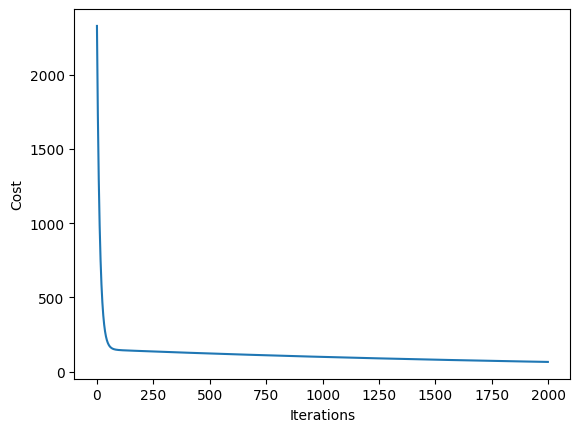

In [64]:
plt.plot(lr_results[0.001]["cost_history"])

plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.show()

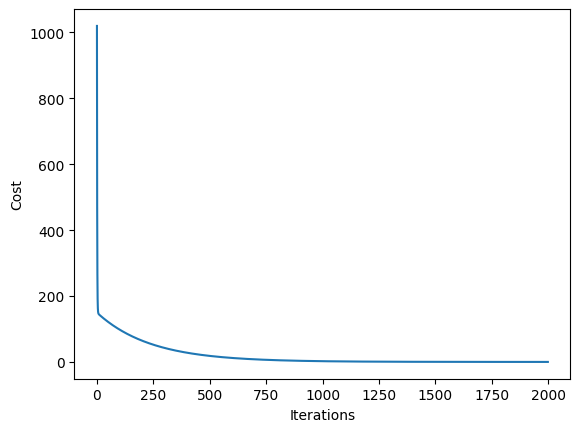

In [65]:
plt.plot(lr_results[0.01]["cost_history"])

plt.xlabel("Iterations")
plt.ylabel("Cost")

plt.show()

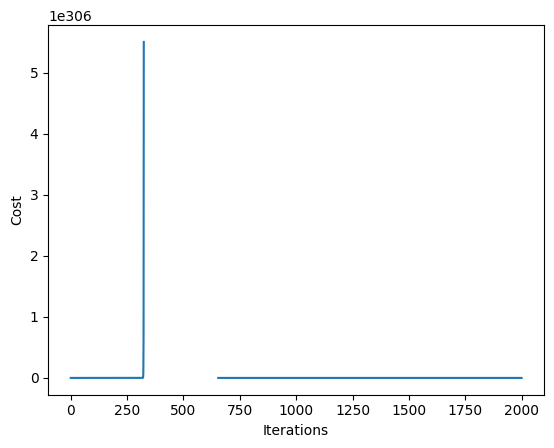

In [66]:
plt.plot(lr_results[0.1]["cost_history"])

plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.show()

In [67]:
lr_comparison_df = pd.DataFrame({
    "Learning Rate": learning_rates,
    "Final theta_0": [lr_results[lr]["theta_0"] for lr in learning_rates],
    "Final theta_1": [lr_results[lr]["theta_1"] for lr in learning_rates],
    "Final Cost": [lr_results[lr]["final_cost"] for lr in learning_rates]
})

display(lr_comparison_df)

,Learning Rate,Final theta_0,Final theta_1,Final Cost
0,0.001,14.399211,9.006398,65.048061
1,0.010,38.440761,5.553057,0.231694
2,0.100,NaN,NaN,0.000000


### Interpretation Questions

1. Which learning rate converged fastest?
2. Which learning rate was too small or too large?
3. What pattern indicates divergence?
4. Why can the best learning rate depend on the scale of \(X\)?

In [38]:
# Which learning rate converged fastest?
# 0.01

# Which learning rate was too small or too large?
# learning_rate = 0.001 was too small
# learning_rate = 0.1 was too large

# What pattern indicates divergence?
# The cost increases from iteration to iteration instead of decreasing, and it can grow extremely large or become NaN, as seen with learning_rate = 0.1

# Why can the best learning rate depend on the scale of X?
# scale of X affects gradient size, and gradient size affects how large each update is. Therefore, the appropriate learning rate depends on the scale of X

# Task 5 — Multiple Linear Regression by Manual Substitution

A house-price model is:

$$
\hat{y}
=
\theta_0
+
\theta_1x_1
+
\theta_2x_2
+
\theta_3x_3
$$

Where:

- \(x_1\): area in m²
- \(x_2\): number of bedrooms
- \(x_3\): property age in years

The learned parameters are:

- \(\theta_0 = 120\)
- \(\theta_1 = 3.5\)
- \(\theta_2 = 25\)
- \(\theta_3 = -2\)

Prices are measured in thousands.

### Required

1. Predict the price for each property.
2. Calculate residuals.
3. Interpret every coefficient.
4. Predict a new property with:
   - Area = 180
   - Bedrooms = 4
   - Age = 8
5. Explain “holding other features constant.”

In [39]:
task5_df = pd.DataFrame({
    "area_m2": [100, 140, 180, 220],
    "bedrooms": [2, 3, 4, 5],
    "property_age": [20, 12, 8, 4],
    "actual_price_thousands": [470, 650, 845, 1035]
})

theta_0 = 120
theta_1 = 3.5
theta_2 = 25
theta_3 = -2

display(task5_df)

,area_m2,bedrooms,property_age,actual_price_thousands
0,100,2,20,470
1,140,3,12,650
2,180,4,8,845
3,220,5,4,1035


In [40]:
task5_df["predicted_price"] = (
    theta_0
    + theta_1 * task5_df["area_m2"]
    + theta_2 * task5_df["bedrooms"]
    + theta_3 * task5_df["property_age"]
)

task5_df["residual"] = task5_df["actual_price_thousands"] - task5_df["predicted_price"]

display(task5_df)

,area_m2,bedrooms,property_age,actual_price_thousands,predicted_price,residual
0,100,2,20,470,480.0,-10.0
1,140,3,12,650,661.0,-11.0
2,180,4,8,845,834.0,11.0
3,220,5,4,1035,1007.0,28.0


In [41]:
new_area, new_bedrooms, new_age = 180, 4, 8

new_price = theta_0 + theta_1 * new_area + theta_2 * new_bedrooms + theta_3 * new_age

print(f"Predicted price for the new property: {new_price:.2f} (thousands)")

Predicted price for the new property: 834.00 (thousands)


### Interpretation Questions

1. What does the area coefficient mean?
2. Why is the property-age coefficient negative?
3. Can the size of coefficients be compared directly when units differ?
4. Does a negative coefficient prove causation?

In [42]:
# What does the area coefficient mean?
# Holding bedrooms and age constant, each extra square meter of area adds about 3.5 (thousand) to the predicted price.

# Why is the property-age coefficient negative?
# Older properties tend to be worth less (more wear, outdated features), so price decreases as age increases, holding other features constant.

# Can the size of coefficients be compared directly when units differ?
# No

# Does a negative coefficient prove causation?
# No

# Task 6 — Vectorized Multiple Regression

Use the vectorized equation:

$$
\hat{y} = X\theta
$$

Include an intercept column of ones in \(X\).

### Required

1. Build the design matrix manually.
2. Build the parameter vector.
3. Calculate all predictions using matrix multiplication.
4. Verify one row using manual substitution.
5. Calculate residuals and MSE.
6. Explain why vectorization is useful.

In [43]:
task6_df = pd.DataFrame({
    "x1": [2, 4, 6, 8],
    "x2": [1, 3, 2, 5],
    "y": [14, 25, 31, 46]
})

theta = np.array([5, 3, 2])  # intercept, x1 coefficient, x2 coefficient

display(task6_df)

,x1,x2,y
0,2,1,14
1,4,3,25
2,6,2,31
3,8,5,46


In [44]:
X_design = np.column_stack([
    np.ones(len(task6_df)),
    task6_df["x1"],
    task6_df["x2"]
])

display(X_design)

array([[1., 2., 1.],
       [1., 4., 3.],
       [1., 6., 2.],
       [1., 8., 5.]])

In [46]:
y_pred = X_design.dot(theta)
print("Predictions:", y_pred)

Predictions: [13. 23. 27. 39.]


In [68]:
manual_row0 = theta[0] + theta[1] * task6_df["x1"][0] + theta[2] * task6_df["x2"][0]
print("Manual calculation for row 0:", manual_row0)

Manual calculation for row 0: 13


In [48]:
residuals = task6_df["y"].values - y_pred
mse = np.mean(residuals ** 2)

print("Residuals:", residuals)
print("MSE:", mse)

Residuals: [1. 2. 4. 7.]
MSE: 17.5


### Interpretation Questions

1. Why do we add a column of ones?
2. What are the dimensions of \(X\), \(	heta\), and \(\hat{y}\)?
3. How does matrix multiplication replace repeated manual calculations?

In [69]:
# Why do we add a column of ones?
# so that the intercept (theta_0) can be included

# What are the dimensions of X, theta, and y_hat?
# 4 x 3

# How does matrix multiplication replace repeated manual calculations?
# X . theta computes theta_0*1 + theta_1*x1 + theta_2*x2 for every row
# which is equivalent to doing the manual substitution formula once per row but without writing a loop.

# Task 7 — Simple Linear Regression with `scikit-learn`

Use `LinearRegression` to predict delivery time from distance.

### Required

1. Split the data.
2. Train the model.
3. Print `intercept_` and `coef_`.
4. Predict the test set.
5. Calculate MAE, MSE, RMSE, and R².
6. Create a residual table.
7. Plot the best-fit line.
8. Predict delivery time for 18 km.

In [70]:
task7_df = pd.DataFrame({
    "distance_km": [2, 4, 5, 7, 9, 11, 13, 15, 17, 20, 23, 26],
    "delivery_time_minutes": [12, 17, 20, 26, 31, 36, 42, 47, 52, 61, 68, 76]
})

display(task7_df)

,distance_km,delivery_time_minutes
0,2,12
1,4,17
2,5,20
3,7,26
4,9,31
5,11,36
6,13,42
7,15,47
8,17,52
9,20,61


In [71]:
X = task7_df[["distance_km"]]
y = task7_df["delivery_time_minutes"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [72]:
task7_model = LinearRegression()
task7_model.fit(X_train, y_train)

LinearRegression()

In [73]:
print("Intercept:", task7_model.intercept_)
print("Coefficient:", task7_model.coef_[0])

Intercept: 6.846041055718484
Coefficient: 2.6671554252199408


In [74]:
y_pred = task7_model.predict(X_test)
y_pred

array([68.19061584, 60.18914956, 12.18035191])

In [75]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

In [78]:
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 0.39393939393939564
MSE: 0.24211321425397792
RMSE: 0.49205001194388553
R2: 0.9996099142627487


### Interpretation Questions

1. What does `coef_[0]` mean?
2. Why are test metrics more meaningful than training metrics?
3. What does a positive residual mean when residual = actual − predicted?
4. Does `LinearRegression` expose a learning rate?

In [79]:
# What does coef_[0] mean?
# the coefficient ot the first feature

# Why are test metrics more meaningful than training metrics?
# becaues ir measures the performance on unseen data, whice is the more accruate results

# What does a positive residual mean when residual = actual − predicted?
# the predicted value is less than the actual

# Does LinearRegression expose a learning rate?
# no

# Task 8 — Multiple Linear Regression with `scikit-learn`

Predict employee performance using:

- Training hours
- Experience years
- Overtime hours

### Required

1. Train/test split.
2. Train Multiple Linear Regression.
3. Create a coefficient table.
4. Evaluate the model.
5. Predict a new employee.
6. Interpret all coefficients while holding other features constant.
7. Compare actual and predicted values.

In [80]:
task8_df = pd.DataFrame({
    "training_hours": [4, 8, 12, 5, 16, 20, 7, 14, 18, 10, 22, 25, 9, 13, 17, 21],
    "experience_years": [1, 2, 3, 1, 5, 6, 2, 4, 7, 3, 8, 9, 2, 5, 6, 8],
    "overtime_hours": [18, 15, 14, 20, 10, 8, 17, 12, 9, 15, 7, 6, 19, 11, 10, 7],
    "performance_score": [52, 58, 62, 50, 73, 81, 57, 69, 78, 64, 86, 91, 54, 71, 76, 87]
})

display(task8_df)

,training_hours,experience_years,overtime_hours,performance_score
0,4,1,18,52
1,8,2,15,58
2,12,3,14,62
3,5,1,20,50
4,16,5,10,73
5,20,6,8,81
6,7,2,17,57
7,14,4,12,69
8,18,7,9,78
9,10,3,15,64


In [81]:
X = task8_df[["training_hours", "experience_years", "overtime_hours"]]
y = task8_df["performance_score"]

In [82]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [83]:
model = LinearRegression()

In [84]:
model.fit(X_train, y_train)

LinearRegression()

In [85]:
y_pred = model.predict(X_test)

In [87]:
task8_coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

print("Intercept:", model.intercept_)
display(task8_coef_df)

Intercept: 66.78817674679938


,Feature,Coefficient
0,training_hours,0.284304
1,experience_years,2.517077
2,overtime_hours,-1.032869


In [88]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 0.7085624272584976
MSE: 0.8465623303247182
RMSE: 0.9200882187729165
R2: 0.9941891903538415


### Interpretation Questions

1. Which coefficient is positive and which is negative?
2. What does the overtime coefficient mean?
3. Why must coefficient interpretation include “holding other variables constant”?
4. Can we rank importance using raw coefficient size alone?

In [59]:
# Which coefficient is positive and which is negative?
# positive: "training_hours" and "experience_years"
# negative: "overtime_hours"

# What does the overtime coefficient mean?
# when "overtime_hours" increses the predicted value decrease

# Why must coefficient interpretation include “holding other variables constant”?
# because multiple features affect the prediction at the same time
# holding other variables constant allows us to interpret the effect of one feature independently

# Can we rank importance using raw coefficient size alone?
# no

# Task 9 — Debugging Regression Training

For each case below, explain the most likely problem and the correct action.

### Case A
The cost starts at 500 and becomes:

`500, 900, 1800, 4200, 10000`

### Case B
The cost becomes:

`500, 499.8, 499.6, 499.4, 499.2`

after many iterations.

### Case C
Training R² is high, but test R² is much lower.

### Case D
All predictions are systematically lower than actual values.

### Case E
The slope is positive, but a student claims this proves that \(X\) causes \(Y\).

In [89]:
# Case A:
# The learning rate is too high, causing the cost to increase
# Reduce the learning rate

# Case B:
# The learning rate is too low, so the cost decreases very slowly
# Increase the learning rate

# Case C:
# The model is likely overfitting the training data
# Use a simpler model or improve generalization

# Case D:
# The model is systematically underpredicting the target
# Check the model, features, or intercept and investigate the bias

# Case E:
# A positive slope shows an association between X and Y, not causation
# A positive coefficient does not prove that X causes Y

# Final Challenge — Complete Regression Workflow

Choose either Simple or Multiple Linear Regression.

Your analysis must include:

1. Problem definition
2. Feature(s) and target
3. Visualization
4. Train/test split
5. Model training
6. Intercept and coefficient interpretation
7. Predictions
8. MAE, MSE, RMSE, and R²
9. Residual table
10. Best-fit line if applicable
11. Three insights
12. Two limitations
13. Final conclusion

**1. Problem definition:** Predict a store's monthly sales from its monthly advertising spend, so the business can estimate expected sales for a given marketing budget.

**2. Feature and target:** Feature (X) = `advertising_spend` (in thousands of currency units). Target (y) = `monthly_sales` (units sold).

In [90]:
df = pd.DataFrame({
    "advertising_spend": [2.1, 3.5, 4.8, 5.2, 6.0, 6.9, 7.5, 8.3, 9.1, 10.0, 10.8, 11.5, 12.4, 13.0, 14.2],
    "monthly_sales":      [25, 34, 41, 44, 50, 55, 60, 66, 71, 78, 83, 88, 95, 99, 108]
})

display(df)

,advertising_spend,monthly_sales
0,2.1,25
1,3.5,34
2,4.8,41
3,5.2,44
4,6.0,50
5,6.9,55
6,7.5,60
7,8.3,66
8,9.1,71
9,10.0,78


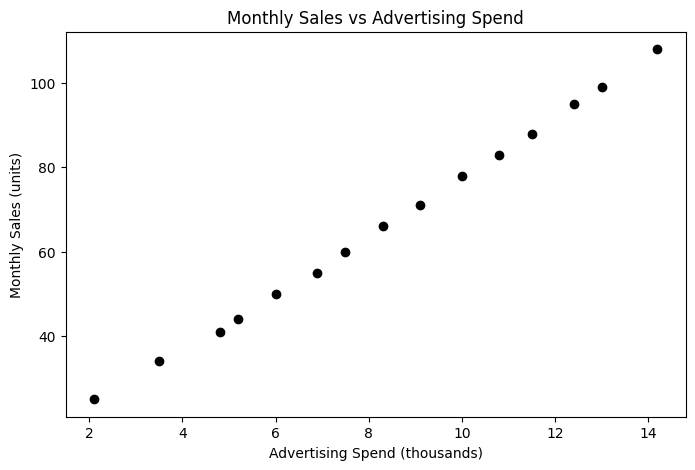

In [92]:
plt.figure(figsize=(8,5))
plt.scatter(df["advertising_spend"], df["monthly_sales"], color="black")
plt.xlabel("Advertising Spend (thousands)")
plt.ylabel("Monthly Sales (units)")
plt.title("Monthly Sales vs Advertising Spend")
plt.show()

In [98]:
X = df[["advertising_spend"]]
y = df["monthly_sales"]

In [99]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [100]:
model = LinearRegression()

In [101]:
model.fit(X_train, y_train)

LinearRegression()

In [102]:
y_pred = model.predict(X_test)

In [103]:
print("Intercept:", model.intercept_)
print("Coefficient:", model.coef_[0])

Intercept: 7.7784334730340134
Coefficient: 7.007461143791464


In [104]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print("MSE:", mse)
print("RMSE:", rmse)
print("R2:", r2)
print("MAE:", mae)

MSE: 2.144596510426423
RMSE: 1.4644440960400034
R2: 0.9971937527487877
MAE: 1.0056966135637044


In [105]:
final_residuals_df = pd.DataFrame({
    "advertising_spend": X_test["advertising_spend"].values,
    "actual": y_test.values,
    "predicted": y_pred,
    "residual": y_test.values - y_pred
})

display(final_residuals_df)

,advertising_spend,actual,predicted,residual
0,10.0,78,77.853045,0.146955
1,11.5,88,88.364237,-0.364237
2,2.1,25,22.494102,2.505898


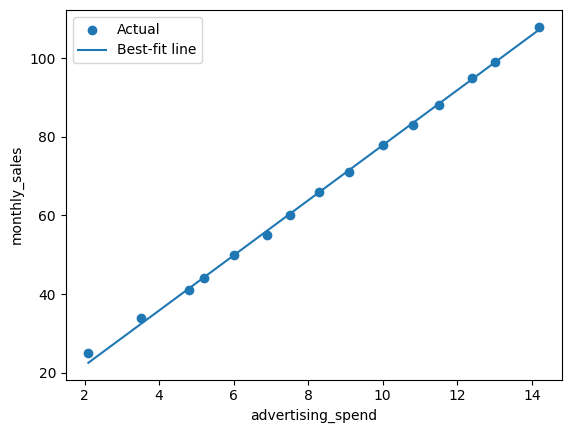

In [106]:
plt.scatter(X, y, label="Actual")

plt.plot(X, model.predict(X), label="Best-fit line")

plt.xlabel("advertising_spend")
plt.ylabel("monthly_sales")
plt.legend()
plt.show()

**11. Three insights**
1. There is a strong positive linear relationship between advertising spend and monthly sales.
2. The model's average prediction error (MAE) is small relative to the scale of monthly sales, so the linear model fits this data well.
3. Sales increase fairly consistently with spend across the observed range, suggesting diminishing returns have not yet appeared in this dataset.

**12. Two limitations**
1. The dataset is small, so the model may not generalize well to spending levels far outside the observed range.
2. The model assumes a purely linear relationship and does not account for other factors that could affect sales.

**13. Final conclusion**
Advertising spend is a strong linear predictor of monthly sales in this dataset, and the trained model could be used to estimate expected sales for a proposed advertising budget, keeping in mind the limitations above regarding dataset size and the linear only assumption.